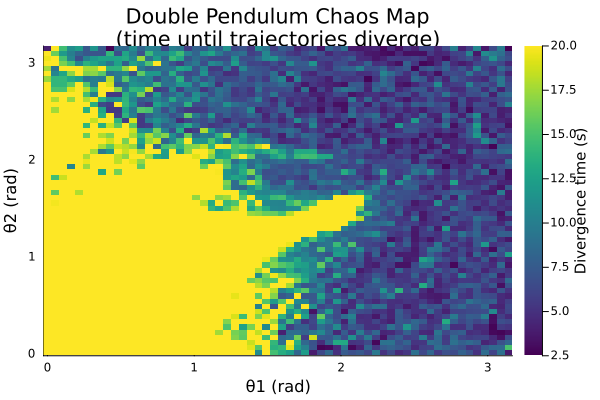

In [1]:
using DifferentialEquations
using Plots

# Double pendulum equations of motion
# State vector: u = [θ1, ω1, θ2, ω2]
function double_pendulum!(du, u, p, t)
    θ1, ω1, θ2, ω2 = u
    m1, m2, L1, L2, g = p

    Δ = θ1 - θ2
    denom1 = L1 * (2m1 + m2 - m2 * cos(2Δ))
    denom2 = L2 * (2m1 + m2 - m2 * cos(2Δ))

    du[1] = ω1
    du[2] = (-g * (2m1 + m2) * sin(θ1) - m2 * g * sin(θ1 - 2θ2) -
             2 * sin(Δ) * m2 * (ω2^2 * L2 + ω1^2 * L1 * cos(Δ))) / denom1

    du[3] = ω2
    du[4] = (2 * sin(Δ) * (ω1^2 * L1 * (m1 + m2) + g * (m1 + m2) * cos(θ1) +
             ω2^2 * L2 * m2 * cos(Δ))) / denom2
end

# Physical parameters: masses, lengths, gravity
m1, m2 = 1.0, 1.0
L1, L2 = 1.0, 1.0
g = 9.81
p = (m1, m2, L1, L2, g)

# Simulate two pendulums with a tiny initial perturbation and measure
# how fast their trajectories diverge (chaos indicator)
function divergence_time(θ1_0, θ2_0; ϵ=1e-6, t_max=20.0, threshold=1.0)
    u0_a = [θ1_0, 0.0, θ2_0, 0.0]
    u0_b = [θ1_0 + ϵ, 0.0, θ2_0, 0.0]

    prob_a = ODEProblem(double_pendulum!, u0_a, (0.0, t_max), p)
    prob_b = ODEProblem(double_pendulum!, u0_b, (0.0, t_max), p)

    sol_a = solve(prob_a, Tsit5(), saveat=0.05)
    sol_b = solve(prob_b, Tsit5(), saveat=0.05)

    for (i, t) in enumerate(sol_a.t)
        dist = abs(sol_a.u[i][1] - sol_b.u[i][1]) + abs(sol_a.u[i][3] - sol_b.u[i][3])
        if dist > threshold
            return t
        end
    end
    return t_max  # never diverged within threshold
end

# Build a grid of initial angles and compute divergence time for each
n_grid = 60
θ1_range = range(0, π, length=n_grid)
θ2_range = range(0, π, length=n_grid)

chaos_map = zeros(n_grid, n_grid)

for (i, θ1_0) in enumerate(θ1_range)
    for (j, θ2_0) in enumerate(θ2_range)
        chaos_map[i, j] = divergence_time(θ1_0, θ2_0)
    end
end

heatmap(θ1_range, θ2_range, chaos_map',
    xlabel="θ1 (rad)",
    ylabel="θ2 (rad)",
    title="Double Pendulum Chaos Map\n(time until trajectories diverge)",
    color=:viridis,
    colorbar_title="Divergence time (s)")